# Short model-based advection initializer competition (09/01/26)

목적은 advection 추정 자체를 복잡하게 만드는 것이 아니라, 방향을 알아야 구성되는 directional lag-432 Vecchia corridor에 넣을 **빠르고 안정적인 seed**를 고르는 것이다.

비교 방법: `M0_zero`, `M3_fft`, `S1_fixed_stencil`, `S2_pairwise_polar`, `S3_fft_gated`, `S4_iterative_corridor`. Synthetic 비교는 4방향 × 2속도 × 3 nuisance 시작값 = 24 paired cases이며, 각 seed로 동일한 7-parameter fit (`max_eval=12`)을 수행했다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
SYN = REPO / 'outputs/summer_26/synthetic_short_model_initializer_competition_corridor432_083126'
SCREEN = REPO / 'outputs/summer_26/synthetic_short_model_initializer_screen_trustregion_083126'
REAL = REPO / 'outputs/day/estimates/realdata_short_model_initializer_timing_090126'
init = pd.read_csv(SCREEN / 'initializer_results.csv')
full = pd.read_csv(SYN / 'full_fit_results.csv')
real = pd.read_csv(REAL / 'initializer_timings.csv')
len(init), len(full), len(real)

(144, 144, 6)

## 1. Synthetic seed accuracy and stable initializer timing

Initializer timing은 장시간 full-fit run 중 시스템 부하 변동을 피하기 위해 별도 screen run을 사용한다.

,method,n,mean_seed_error,median_seed_error,max_seed_error,mean_angle_error_deg,correct_quadrant_rate,mean_seed_s,median_seed_s,time_ratio_vs_M3
0,M0_zero,24,0.161555,0.161555,0.215407,NaN,0.000000,0.000000,0.000000,0.000000
1,M3_fft,24,0.022681,0.019954,0.037216,5.503191,1.000000,0.004308,0.003212,1.000000
2,S1_fixed_stencil,24,0.103619,0.078065,0.556717,20.417642,0.958333,0.088626,0.081365,20.570392
3,S2_pairwise_polar,24,0.051723,0.040756,0.182773,9.788513,0.916667,0.017265,0.016024,4.007156
4,S3_fft_gated,24,0.030788,0.027293,0.060252,4.767584,1.000000,0.015116,0.014422,3.508573
5,S4_iterative_corridor,24,0.011350,0.010881,0.025287,2.223963,1.000000,2.392714,2.379096,555.356134


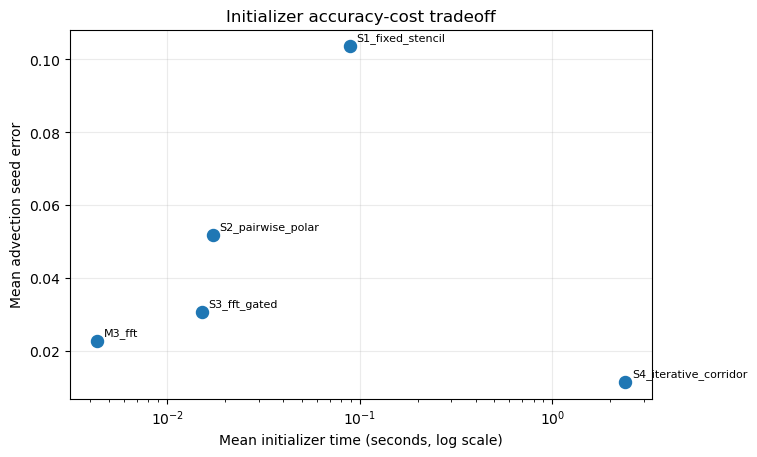

In [2]:
init_summary = (init.groupby('method', as_index=False)
    .agg(n=('seed_error_euclid','size'),
         mean_seed_error=('seed_error_euclid','mean'),
         median_seed_error=('seed_error_euclid','median'),
         max_seed_error=('seed_error_euclid','max'),
         mean_angle_error_deg=('seed_angle_error_deg','mean'),
         correct_quadrant_rate=('correct_quadrant','mean'),
         mean_seed_s=('seed_total_s','mean'),
         median_seed_s=('seed_total_s','median')))
m3_s = init_summary.loc[init_summary.method.eq('M3_fft'), 'mean_seed_s'].iloc[0]
init_summary['time_ratio_vs_M3'] = init_summary.mean_seed_s / m3_s
display(init_summary.round(6))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
plot = init_summary[init_summary.method.ne('M0_zero')]
ax.scatter(plot.mean_seed_s, plot.mean_seed_error, s=75)
for row in plot.itertuples():
    ax.annotate(row.method, (row.mean_seed_s, row.mean_seed_error), xytext=(5,4), textcoords='offset points', fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Mean initializer time (seconds, log scale)')
ax.set_ylabel('Mean advection seed error')
ax.set_title('Initializer accuracy-cost tradeoff')
ax.grid(alpha=.25)
plt.show()

## 2. Downstream seven-parameter corridor fit

서로 다른 seed가 서로 다른 corridor geometry를 만들기 때문에 own-corridor NLL 대신 모든 최종 parameter를 동일한 oracle-direction corridor에서 재평가한 `common_nll_regret`을 사용한다. Failure threshold는 regret > 0.002 또는 standardized 7-parameter RMSE > 0.5이다.

,method,n,mean_common_nll_regret,median_common_nll_regret,nll_failure_rate,mean_parameter_error,median_parameter_error,parameter_failure_rate,mean_final_advection_error,median_end_to_end_s
0,M0_zero,24,0.005462,0.001707,0.416667,0.483236,0.272006,0.208333,0.118467,7.330319
1,M3_fft,24,0.001065,0.001040,0.208333,0.200320,0.253756,0.000000,0.010272,8.289780
2,S1_fixed_stencil,24,0.003702,0.001184,0.333333,0.554363,0.251066,0.208333,0.153741,7.175656
3,S2_pairwise_polar,24,0.002513,0.001354,0.333333,0.366830,0.267843,0.125000,0.092129,7.619750
4,S3_fft_gated,24,0.000983,0.000261,0.166667,0.197739,0.251635,0.000000,0.011676,7.229652
5,S4_iterative_corridor,24,0.000368,0.000000,0.000000,0.177536,0.171014,0.000000,0.011617,15.397895


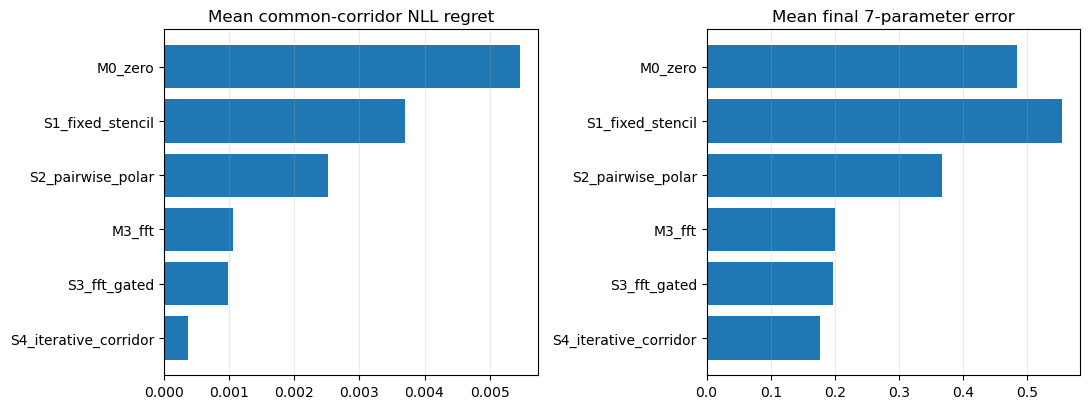

In [3]:
full = full.copy()
full['nll_failure'] = full.common_nll_regret > 0.002
full['parameter_failure'] = full.final_standardized_rmse_7param > 0.5
full_summary = (full.groupby('method', as_index=False)
    .agg(n=('dataset_id','size'),
         mean_common_nll_regret=('common_nll_regret','mean'),
         median_common_nll_regret=('common_nll_regret','median'),
         nll_failure_rate=('nll_failure','mean'),
         mean_parameter_error=('final_standardized_rmse_7param','mean'),
         median_parameter_error=('final_standardized_rmse_7param','median'),
         parameter_failure_rate=('parameter_failure','mean'),
         mean_final_advection_error=('final_seed_error_euclid','mean'),
         median_end_to_end_s=('end_to_end_s','median')))
display(full_summary.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
order = full_summary.sort_values('mean_common_nll_regret').method
axes[0].barh(order, full_summary.set_index('method').loc[order, 'mean_common_nll_regret'])
axes[0].set_title('Mean common-corridor NLL regret')
axes[1].barh(order, full_summary.set_index('method').loc[order, 'mean_parameter_error'])
axes[1].set_title('Mean final 7-parameter error')
for ax in axes: ax.grid(axis='x', alpha=.25)
plt.tight_layout(); plt.show()

## 3. Actual GEMS one-day initializer timing

2024-07-01, 114×159 = 18,126 cells/hour, 8 hours, 145,008 total rows (131,428 valid). S1 uses stride-3 (2,014 cells/hour, 14,582 valid targets, m≤16). S4 rebuilds the full 131,428-target directional corridor twice.

In [4]:
display(real[['method','seed_lat','seed_lon','seed_total_s','time_ratio_vs_M3','selected_candidate']].round(6))

,method,seed_lat,seed_lon,seed_total_s,time_ratio_vs_M3,selected_candidate
0,M0_zero,0.000000,0.000000,0.000000,0.000000,zero
1,M3_fft,-0.044000,-0.252000,0.023361,1.000000,tau1_fft_exact
2,S1_fixed_stencil,-0.013948,-0.249203,0.731877,31.328560,zero_then_fixed_stencil
3,S2_pairwise_polar,-0.007545,-0.212757,0.050229,2.150074,pairwise_polar_global
4,S3_fft_gated,-0.022000,-0.220500,0.066061,2.827778,fft_local
5,S4_iterative_corridor,-0.022062,-0.214333,34.779324,1488.755978,m3_iterative_corridor


## 결론

- **M3 FFT를 기본 initializer로 유지**하는 것이 가장 합리적이다. Synthetic에서 평균 seed error 0.0227, quadrant 100%, 실제 하루 0.023초였다.
- S1은 20배 이상 느리고 방향/nuisance에 따라 큰 실패가 있어 제외한다.
- S2 standalone polar profile은 nuisance misspecification에서 잘못된 속도로 이동하므로 제외한다.
- **S3는 유일한 실용적 보조 후보**다. M3 반 격자 trust region 때문에 quadrant를 보존하고 평균 angle error를 5.50°→4.77°로 줄였다. Full-fit mean common NLL regret도 0.001065→0.000983으로 소폭 감소했다. 실제 자료에서 0.066초이며 S4와 유사한 seed를 냈다. 하지만 synthetic Euclidean seed error는 M3보다 나쁘므로 M3의 확정적 대체가 아니라 bounded optional refinement다. 안전한 기본값은 FFT signal이 약할 때 global polar로 가지 않고 M3를 그대로 유지한다.
- S4는 seed error를 가장 많이 줄였지만 실제 하루 34.8초로 M3보다 약 1,489배 느렸다. Initialization이라는 목적에는 과도하다.